# 04 - Feature Relationships

**Milestone 1 — Part 4.A**: Investigate correlations, F-statistics, and feature selection.

## Objectives
- Compute pairwise correlation matrix and heatmap
- Compute F-statistic (f_regression) for all features vs target
- Run forward and backward sequential feature selection
- Identify strongly correlated feature pairs

## Expected Outcomes
| Deliverable | Description |
|---|---|
| Correlation heatmap | Visual of pairwise correlations |
| F-statistic bar chart | Feature importance ranking via f_regression |
| Forward selection result | Top-k features chosen by forward SFS |
| Backward selection result | Top-k features chosen by backward SFS |
| Comparison notes | Agreement/disagreement across methods |

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression, SelectKBest, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TARGET = "taxvaluedollarcnt"

df = pd.read_csv("zillow_cleaned.csv")
print(f"Shape: {df.shape}")



Shape: (74303, 26)


In [5]:
df.describe()

,basementsqft,bedroomcnt,calculatedbathnbr,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet50,fireplacecnt,garagecarcnt,garagetotalsqft,latitude,...,roomcnt,storytypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,taxdelinquencyflag,taxvaluedollarcnt
count,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,7.430300e+04,...,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,7.430300e+04
mean,515.110843,3.065125,2.279571,1259.938872,1748.688667,1263.812107,1.020161,1.933327,403.926894,3.401093e+07,...,1.505296,0.000673,1.071747,251.552912,171.545193,1967.946705,1.101153,0.002315,0.038262,4.376191e+05
std,18.219506,1.104204,0.916675,180.983332,846.347845,194.117885,0.167145,0.339493,154.765232,2.657014e+05,...,2.844554,0.025932,0.964572,38.725566,5.930196,23.366085,0.320404,0.048057,0.191830,3.531914e+05
min,38.000000,0.000000,1.000000,44.000000,152.000000,44.000000,1.000000,0.000000,0.000000,3.333953e+07,...,0.000000,0.000000,1.000000,11.000000,12.000000,1824.000000,1.000000,0.000000,0.000000,1.000000e+03
25%,515.000000,2.000000,2.000000,1252.000000,1182.000000,1255.000000,1.000000,2.000000,434.000000,3.381740e+07,...,0.000000,0.000000,1.000000,250.000000,171.500000,1953.000000,1.000000,0.000000,0.000000,2.035720e+05
50%,515.000000,3.000000,2.000000,1252.000000,1538.000000,1255.000000,1.000000,2.000000,434.000000,3.402128e+07,...,0.000000,0.000000,1.000000,250.000000,171.500000,1969.000000,1.000000,0.000000,0.000000,3.532570e+05
75%,515.000000,4.000000,3.000000,1252.000000,2087.000000,1255.000000,1.000000,2.000000,434.000000,3.417710e+07,...,0.000000,0.000000,1.000000,250.000000,171.500000,1986.000000,1.000000,0.000000,0.000000,5.550000e+05
max,3560.000000,16.000000,10.000000,6743.000000,35640.000000,8880.000000,5.000000,14.000000,4251.000000,3.481877e+07,...,14.000000,1.000000,237.000000,2480.000000,868.000000,2016.000000,6.000000,1.000000,1.000000,2.377148e+06


In [ ]:
#problematic columns
# basementsqft (impute 0), finishedfloor1squarefeet (has to be less than total), finishedsquarefeet50 (has to be less than total), fireplacecnt (impute 0), garagecount (impute 0), garagetotalsqft (should slightly agree with garagecount), roomcnt (should be larger than sum of bed+bath), propertycountylandusecode (gave me errors)

In [9]:
df = df.drop(['basementsqft', 'finishedfloor1squarefeet', 'finishedsquarefeet50', 'fireplacecnt', 'garagecarcnt','garagetotalsqft','roomcnt','propertycountylandusecode'],axis=1)

In [10]:
df.describe()

,bedroomcnt,calculatedbathnbr,calculatedfinishedsquarefeet,latitude,longitude,lotsizesquarefeet,poolcnt,propertylandusetypeid,regionidzip,storytypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,taxdelinquencyflag,taxvaluedollarcnt
count,74303.000000,74303.000000,74303.000000,7.430300e+04,7.430300e+04,7.430300e+04,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,7.430300e+04
mean,3.065125,2.279571,1748.688667,3.401093e+07,-1.182039e+08,2.800140e+04,0.209224,261.789578,96579.164600,0.000673,1.071747,251.552912,171.545193,1967.946705,1.101153,0.002315,0.038262,4.376191e+05
std,1.104204,0.916675,846.347845,2.657014e+05,3.602698e+05,1.186592e+05,0.406758,4.938990,3361.379226,0.025932,0.964572,38.725566,5.930196,23.366085,0.320404,0.048057,0.191830,3.531914e+05
min,0.000000,1.000000,152.000000,3.333953e+07,-1.194754e+08,2.360000e+02,0.000000,31.000000,95982.000000,0.000000,1.000000,11.000000,12.000000,1824.000000,1.000000,0.000000,0.000000,1.000000e+03
25%,2.000000,2.000000,1182.000000,3.381740e+07,-1.184144e+08,5.893500e+03,0.000000,261.000000,96197.000000,0.000000,1.000000,250.000000,171.500000,1953.000000,1.000000,0.000000,0.000000,2.035720e+05
50%,3.000000,2.000000,1538.000000,3.402128e+07,-1.181787e+08,7.200000e+03,0.000000,261.000000,96389.000000,0.000000,1.000000,250.000000,171.500000,1969.000000,1.000000,0.000000,0.000000,3.532570e+05
75%,4.000000,3.000000,2087.000000,3.417710e+07,-1.179316e+08,1.053350e+04,0.000000,266.000000,96987.000000,0.000000,1.000000,250.000000,171.500000,1986.000000,1.000000,0.000000,0.000000,5.550000e+05
max,16.000000,10.000000,35640.000000,3.481877e+07,-1.175546e+08,6.971010e+06,1.000000,275.000000,399675.000000,1.000000,237.000000,2480.000000,868.000000,2016.000000,6.000000,1.000000,1.000000,2.377148e+06


## 1. Correlation Matrix

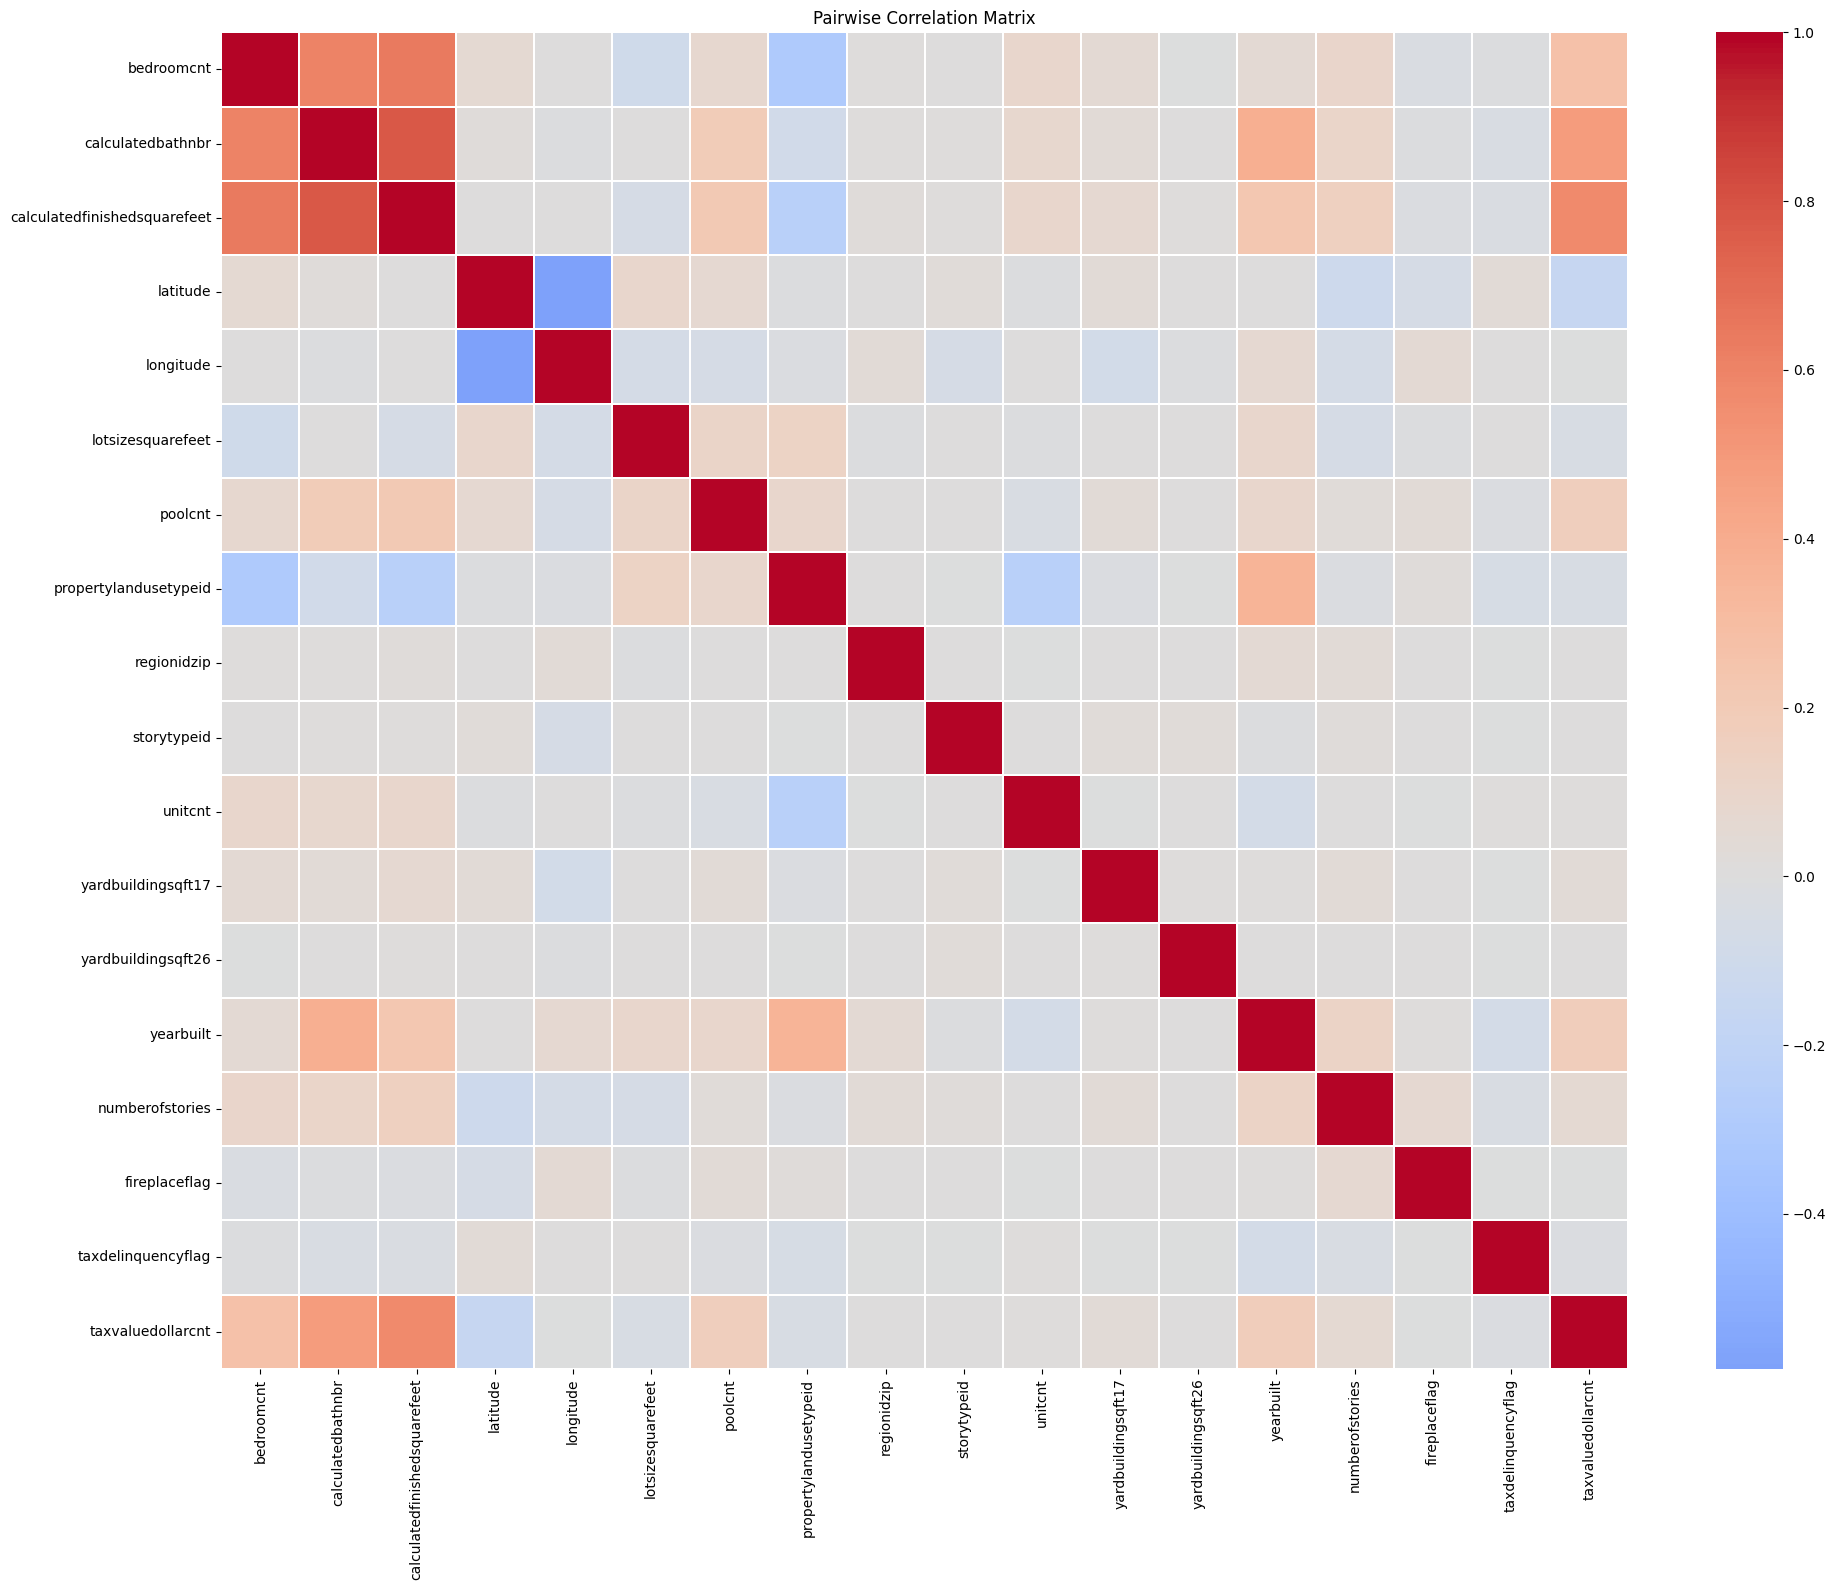

In [11]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

In [12]:
# Correlation with the target, sorted
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)

Correlation with target:
calculatedfinishedsquarefeet    0.571458
calculatedbathnbr               0.481226
bedroomcnt                      0.266016
yearbuilt                       0.173614
poolcnt                         0.167991
numberofstories                 0.058962
yardbuildingsqft17              0.038797
unitcnt                         0.012727
storytypeid                     0.009314
yardbuildingsqft26              0.009010
regionidzip                     0.007436
fireplaceflag                  -0.007077
longitude                      -0.007383
taxdelinquencyflag             -0.019991
propertylandusetypeid          -0.039126
lotsizesquarefeet              -0.040009
latitude                       -0.157573
Name: taxvaluedollarcnt, dtype: float64


## 2. F-Statistic (f_regression)

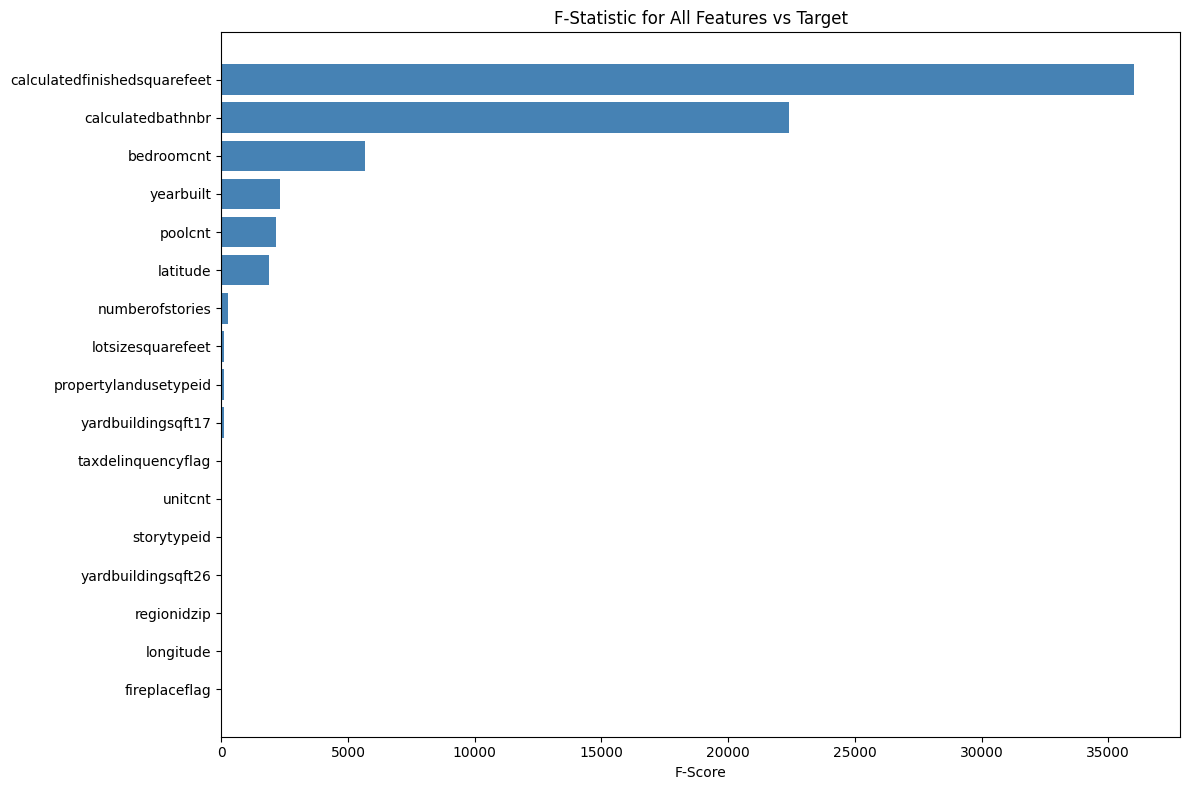

,feature,f_score,p_value
0,calculatedfinishedsquarefeet,36030.253143,0.000000e+00
1,calculatedbathnbr,22391.979432,0.000000e+00
2,bedroomcnt,5658.287215,0.000000e+00
3,yearbuilt,2309.159352,0.000000e+00
4,poolcnt,2157.748385,0.000000e+00
5,latitude,1891.805662,0.000000e+00
6,numberofstories,259.205972,3.208504e-58
7,lotsizesquarefeet,119.127338,1.030982e-27
8,propertylandusetypeid,113.916248,1.420990e-26
9,yardbuildingsqft17,112.005278,3.719875e-26


In [13]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({"feature": X.columns, "f_score": f_scores, "p_value": p_values})
f_df = f_df.sort_values("f_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
plt.barh(f_df["feature"], f_df["f_score"], color="steelblue")
plt.xlabel("F-Score")
plt.title("F-Statistic for All Features vs Target")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

f_df.head(15)

## 3. Forward and Backward Feature Selection

Using `SequentialFeatureSelector` with a simple `LinearRegression` estimator.
Adjust `n_features_to_select` as appropriate.

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

estimator = LinearRegression()
n_select = 6  # TODO: adjust

# Forward selection
sfs_forward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="forward", cv=3, scoring="r2"
)
sfs_forward.fit(X_scaled, y)
forward_features = X.columns[sfs_forward.get_support()].tolist()
print(f"Forward selection ({n_select}): {forward_features}")

Forward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'numberofstories']


In [27]:
# Backward selection
sfs_backward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="backward", cv=3, scoring="r2"
)
sfs_backward.fit(X_scaled, y)
backward_features = X.columns[sfs_backward.get_support()].tolist()
print(f"Backward selection ({n_select}): {backward_features}")

Backward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'numberofstories']


In [28]:
# Compare the two methods
common = set(forward_features) & set(backward_features)
only_forward = set(forward_features) - set(backward_features)
only_backward = set(backward_features) - set(forward_features)

print(f"Common to both:  {common}")
print(f"Only forward:    {only_forward}")
print(f"Only backward:   {only_backward}")

Common to both:  {'calculatedbathnbr', 'latitude', 'calculatedfinishedsquarefeet', 'bedroomcnt', 'numberofstories', 'longitude'}
Only forward:    set()
Only backward:   set()


---
## Discussion 4.A

Describe what you see in the feature relationships and correlations:
- Strongly correlated feature pairs?
- Do correlation, F-statistic, and SFS methods agree or disagree?
- Any surprises?

Our correlations work as expected. The most correalted variable with the tax assessment is square feet of the house. This is highly correlated with bedroom count and bathroom count. It is interesting that lot size is not highly correlated with any variable. 

It is interesting that there is a slgihtly different correlation between latitude and longitude. It is possible that houses in a certain direction are more valuable, but it is surprising this had a difference with the raw data. When using a model, even simple regression, latitude and longitude are both higher priority variables. When allowing only 3 features, besides square feet, latitude and longitude are the next chosen variables. 


The methods do not have major disagreement except for the priority of latitude and longitude. 


---
### Next Notebook → `05_bivariate_analysis.ipynb`